In [31]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
import os
import glob

plt.rcParams["svg.fonttype"] = "none"
plt.rcParams.update({
    "font.family": "Arial",
    "font.size": 6,
    "axes.labelsize": 6,
    "axes.titlesize": 6,
    "xtick.labelsize": 5,
    "ytick.labelsize": 5,
    "xtick.major.size": 1.75,
    "ytick.major.size": 1.75,
    "xtick.minor.size": 1.0,
    "xtick.direction": "in",
    "ytick.direction": "in",
    "ytick.minor.size": 1.0,
    "legend.fontsize": 5,
    "axes.linewidth": 0.5,
})

%matplotlib widget

In [32]:
# Define data folder and figure save folder
data_folder = '../data'
data_folder = os.path.abspath(data_folder)
print(f'Data folder: {data_folder}')

figure_save_folder = '../figures/CKII_pooled'
figure_save_folder = os.path.abspath(figure_save_folder)
os.makedirs(figure_save_folder, exist_ok=True)
print(f'Figures will be saved to: {figure_save_folder}')

speed_threshold = 3
max_freq = 100

Data folder: /Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4/data
Figures will be saved to: /Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4/figures/CKII_pooled


In [45]:
# Find and load all psd_spectrogram_state_speed*.npz files
pattern = os.path.join(data_folder, 'CKII**', f'psd_spectrogram_state_speed{speed_threshold}.npz')
npz_files = glob.glob(pattern, recursive=True)
print(f'Found {len(npz_files)} psd_spectrogram files:')
for f in npz_files:
    print(f'  {f}')

# Pool data from all datasets
psd_run_all = []
psd_rest_all = []
freqs_ref = None

for npz_path in npz_files:
    data = np.load(npz_path)
    freqs = data['freqs']
    psd_move_cells = data['psd_move_cells']
    psd_quiet_cells = data['psd_quiet_cells']

    if freqs_ref is None:
        freqs_ref = freqs

    # Check if frequencies match the reference
    if not np.array_equal(freqs, freqs_ref):
        print(f'WARNING: Frequency mismatch in {os.path.basename(os.path.dirname(npz_path))}')
        print(f'  Expected {len(freqs_ref)} freqs, got {len(freqs)} freqs - skipping this dataset')
        continue

    # Add all cells from this dataset
    for i in range(psd_move_cells.shape[0]):
        psd_run_all.append(psd_move_cells[i])
        psd_rest_all.append(psd_quiet_cells[i])

    print(f'Loaded {os.path.basename(os.path.dirname(npz_path))}: {psd_move_cells.shape[0]} cells')

# Convert to arrays
psd_run_all = np.array(psd_run_all) if psd_run_all else np.array([])
psd_rest_all = np.array(psd_rest_all) if psd_rest_all else np.array([])

print(f'\nTotal pooled cells: {len(psd_run_all)}')
if freqs_ref is not None:
    print(f'Frequency range: {freqs_ref[0]:.2f} - {freqs_ref[-1]:.2f} Hz')
else:
    print('No valid data loaded')

# Normalization option
normalize_by_freq_range = True  # Set to False to skip normalization
norm_freq_min = 4  # Hz
norm_freq_max = 12  # Hz

if normalize_by_freq_range and len(psd_run_all) > 0 and freqs_ref is not None:
    # Find frequency mask for normalization range
    norm_mask = (freqs_ref >= norm_freq_min) & (freqs_ref <= norm_freq_max)
    
    if np.any(norm_mask):
        print(f'\nNormalizing PSDs by total power in {norm_freq_min}-{norm_freq_max} Hz range')
        
        # Normalize each cell's PSD
        for i in range(len(psd_run_all)):
            total_power_run = np.nansum(psd_run_all[i][norm_mask])
            total_power_rest = np.nansum(psd_rest_all[i][norm_mask])
            
            if total_power_run > 0:
                psd_run_all[i] = psd_run_all[i] / total_power_run
            if total_power_rest > 0:
                psd_rest_all[i] = psd_rest_all[i] / total_power_rest
        
        print(f'Normalized {len(psd_run_all)} cells')
    else:
        print(f'\nWARNING: No frequencies in range {norm_freq_min}-{norm_freq_max} Hz, skipping normalization')

Found 4 psd_spectrogram files:
  /Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4/data/CKII_pAce21_PR_20250806/psd_spectrogram_state_speed3.npz
  /Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4/data/CKII_pAce45_PX_20260118/psd_spectrogram_state_speed3.npz
  /Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4/data/CKII_pAce47_PX_20260128/psd_spectrogram_state_speed3.npz
  /Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4/data/CKII_pAce38_PX_20251126/psd_spectrogram_state_speed3.npz
Loaded CKII_pAce21_PR_20250806: 9 cells
Loaded CKII_pAce45_PX_20260118: 16 cells
Loaded CKII_pAce47_PX_20260128: 5 cells
Loaded CKII_pAce38_PX_20251126: 9 cells

Total pooled cells: 39
Frequency range: 1.00 - 100.00 Hz

Normalizing PSDs by total power in 4-12 Hz range
Normalized 39 cells


Saved to /Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4/figures/CKII_pooled/PSD_state_avg_pooled.svg


/opt/homebrew/Caskroom/miniforge/base/envs/AdamLab/lib/python3.11/site-packages/traitlets/traitlets.py:1385: DeprecationWarning: Passing unrecognized arguments to super(Toolbar).__init__().
NavigationToolbar2WebAgg.__init__() missing 1 required positional argument: 'canvas'
This is deprecated in traitlets 4.2.This error will be raised in a future release of traitlets.
  warn(


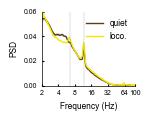

In [53]:
# Plot pooled PSD by behavioral state: Locomotion vs Quiet

run_color = "#f9e800ff"
rest_color = "#563c25"

if len(psd_run_all) > 0 and len(psd_rest_all) > 0:
    # Compute mean and SEM
    psd_run_mean = np.nanmean(psd_run_all, axis=0)
    psd_run_sem = np.nanstd(psd_run_all, axis=0) / np.sqrt(len(psd_run_all))
    psd_rest_mean = np.nanmean(psd_rest_all, axis=0)
    psd_rest_sem = np.nanstd(psd_rest_all, axis=0) / np.sqrt(len(psd_rest_all))
    
    fig, ax = plt.subplots(1, 1, figsize=(1.5, 1.2))
    
    # Plot mean lines
    ax.plot(freqs_ref, psd_rest_mean, color=rest_color, linewidth=1., label='quiet')
    ax.plot(freqs_ref, psd_run_mean, color=run_color, linewidth=1., label='loco.')
    
    
    # Plot SEM shading
    ax.fill_between(
        freqs_ref,
        psd_rest_mean - psd_rest_sem,
        psd_rest_mean + psd_rest_sem,
        color=rest_color,
        alpha=0.2,
        linewidth=0,
    )

    ax.fill_between(
        freqs_ref,
        psd_run_mean - psd_run_sem,
        psd_run_mean + psd_run_sem,
        color=run_color,
        alpha=0.2,
        linewidth=0,
    )
    
    
    ax.set_xscale('log', base=2)
    ax.set_xlim(2, max_freq)
    ax.set_ylim(0, 0.06)
    ticks = [2, 4, 8, 16, 32, 64, 100]
    ticks = [t for t in ticks if t <= max_freq]
    ax.set_xticks(ticks)
    ax.set_xticklabels([str(t) for t in ticks])
    ax.set_xlabel('Frequency (Hz)')
    ax.set_ylabel('PSD')
    ax.legend(frameon=False, fontsize=6)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    #ax.axvspan(4, 9, alpha=0.05, color='blue', linewidth=0)
    ax.axvline(6.4, linestyle = '--', color='gray', linewidth=0.25)
    ax.axvline(11.5, linestyle = '--', color='gray', linewidth=0.25)
    
    plt.tight_layout()
    out_path = os.path.join(figure_save_folder, 'PSD_state_avg_pooled.svg')
    fig.savefig(out_path, dpi=300)
    print(f'Saved to {out_path}')
    plt.show()
else:
    print('No valid PSD data to plot.')

Saved to /Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4/figures/CKII_pooled/PSD_state_avg_pooled_theta_zoom.svg


/opt/homebrew/Caskroom/miniforge/base/envs/AdamLab/lib/python3.11/site-packages/traitlets/traitlets.py:1385: DeprecationWarning: Passing unrecognized arguments to super(Toolbar).__init__().
NavigationToolbar2WebAgg.__init__() missing 1 required positional argument: 'canvas'
This is deprecated in traitlets 4.2.This error will be raised in a future release of traitlets.
  warn(


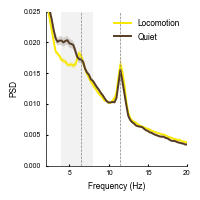

In [44]:
# Plot PSD in theta band (4-8 Hz) zoom

theta_band = (4, 8)

if len(psd_run_all) > 0 and len(psd_rest_all) > 0:
    # Compute mean and SEM
    psd_run_mean = np.nanmean(psd_run_all, axis=0)
    psd_run_sem = np.nanstd(psd_run_all, axis=0) / np.sqrt(len(psd_run_all))
    psd_rest_mean = np.nanmean(psd_rest_all, axis=0)
    psd_rest_sem = np.nanstd(psd_rest_all, axis=0) / np.sqrt(len(psd_rest_all))
    
    fig, ax = plt.subplots(1, 1, figsize=(2, 2))
    
    # Plot mean lines
    ax.plot(freqs_ref, psd_run_mean, color=run_color, linewidth=1.4, label='Locomotion')
    ax.plot(freqs_ref, psd_rest_mean, color=rest_color, linewidth=1.4, label='Quiet')
    
    # Plot SEM shading
    ax.fill_between(
        freqs_ref,
        psd_run_mean - psd_run_sem,
        psd_run_mean + psd_run_sem,
        color=run_color,
        alpha=0.2,
        linewidth=0,
    )
    ax.fill_between(
        freqs_ref,
        psd_rest_mean - psd_rest_sem,
        psd_rest_mean + psd_rest_sem,
        color=rest_color,
        alpha=0.2,
        linewidth=0,
    )
    
    # Highlight theta band
    ax.axvspan(theta_band[0], theta_band[1], alpha=0.1, color='gray', linewidth=0)
    ax.axvline(6.5, linestyle = '--', color='gray', linewidth=0.5)
    ax.axvline(11.5, linestyle = '--', color='gray', linewidth=0.5)
    
    ax.set_xlim(2, 20)
    ax.set_ylim(0, 0.025)
    ax.set_xlabel('Frequency (Hz)')
    ax.set_ylabel('PSD')
    ax.legend(frameon=False, fontsize=6)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    
    plt.tight_layout()
    out_path = os.path.join(figure_save_folder, 'PSD_state_avg_pooled_theta_zoom.svg')
    fig.savefig(out_path, dpi=300)
    print(f'Saved to {out_path}')
    plt.show()
else:
    print('No valid PSD data to plot.')

In [19]:
# Print summary statistics and compare theta power
print('\n=== Summary Statistics ===')
print(f'Total pooled cells: {len(psd_run_all)}')

if len(psd_run_all) > 0 and freqs_ref is not None:
    # Extract theta band power (4-8 Hz)
    theta_mask = (freqs_ref >= 4) & (freqs_ref <= 8)
    
    theta_power_run = np.nanmean(psd_run_all[:, theta_mask], axis=1)
    theta_power_rest = np.nanmean(psd_rest_all[:, theta_mask], axis=1)
    
    print(f'\nTheta power (4-8 Hz):')
    print(f'  Locomotion: mean={np.nanmean(theta_power_run):.4f}, std={np.nanstd(theta_power_run):.4f}')
    print(f'  Quiet: mean={np.nanmean(theta_power_rest):.4f}, std={np.nanstd(theta_power_rest):.4f}')
    
    # Paired test on theta power
    valid = np.isfinite(theta_power_run) & np.isfinite(theta_power_rest)
    if np.sum(valid) >= 3:
        diffs = theta_power_run[valid] - theta_power_rest[valid]
        try:
            shapiro_p = stats.shapiro(diffs).pvalue
        except ValueError:
            shapiro_p = np.nan
        
        if np.isfinite(shapiro_p) and shapiro_p >= 0.05:
            result = stats.ttest_rel(theta_power_run[valid], theta_power_rest[valid])
            test_name = 'paired t-test'
        else:
            result = stats.wilcoxon(theta_power_run[valid], theta_power_rest[valid])
            test_name = 'wilcoxon'
        
        print(f'\nTheta power comparison ({test_name}):')
        print(f'  n={np.sum(valid)}, stat={result.statistic:.3g}, p={result.pvalue:.3g}')


=== Summary Statistics ===
Total pooled cells: 39

Theta power (4-8 Hz):
  Locomotion: mean=0.0137, std=0.0020
  Quiet: mean=0.0156, std=0.0028

Theta power comparison (paired t-test):
  n=39, stat=-6.37, p=1.79e-07


# Example Fitting


In [12]:
from fooof import FOOOF, FOOOFGroup
from fooof.bands import Bands
from fooof.analysis import get_band_peak_fg
from fooof.plts.annotate import plot_annotated_model
from fooof.plts.periodic import plot_peak_params, plot_peak_fits
import pandas as pd

# Use the same moving/quiet colors as the pooled PSD plots
moving_color = "#f9e800ff"  # Locomotion
quiet_color = "#563c25"     # Quiet

# FOOOF model settings (example fits)
min_peak_height = 0.2
aperiodic_mode = 'knee'  # 'knee' or 'fixed'
peak_width_limits = (0.5, 4)
peak_threshold = 3
max_n_peaks = 2

# Define frequency range across which to model the spectrum
freq_range = [1, 20]


Saved to /Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4/figures/CKII_pooled/PSD_state_fooof_annotated_per_cell_1x2/CKII_pAce21_PR_20250806_cell0_fooof_1x2.svg


/opt/homebrew/Caskroom/miniforge/base/envs/AdamLab/lib/python3.11/site-packages/traitlets/traitlets.py:1385: DeprecationWarning: Passing unrecognized arguments to super(Toolbar).__init__().
NavigationToolbar2WebAgg.__init__() missing 1 required positional argument: 'canvas'
This is deprecated in traitlets 4.2.This error will be raised in a future release of traitlets.
  warn(


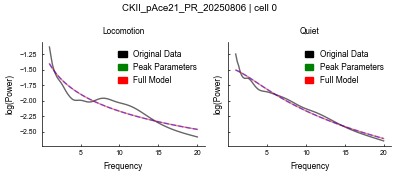

/opt/homebrew/Caskroom/miniforge/base/envs/AdamLab/lib/python3.11/site-packages/traitlets/traitlets.py:1385: DeprecationWarning: Passing unrecognized arguments to super(Toolbar).__init__().
NavigationToolbar2WebAgg.__init__() missing 1 required positional argument: 'canvas'
This is deprecated in traitlets 4.2.This error will be raised in a future release of traitlets.
  warn(


Saved to /Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4/figures/CKII_pooled/PSD_state_fooof_annotated_per_cell_1x2/CKII_pAce21_PR_20250806_cell1_fooof_1x2.svg


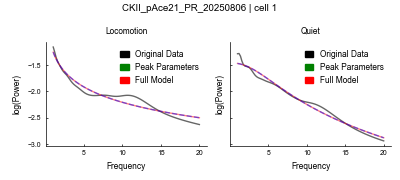

/opt/homebrew/Caskroom/miniforge/base/envs/AdamLab/lib/python3.11/site-packages/traitlets/traitlets.py:1385: DeprecationWarning: Passing unrecognized arguments to super(Toolbar).__init__().
NavigationToolbar2WebAgg.__init__() missing 1 required positional argument: 'canvas'
This is deprecated in traitlets 4.2.This error will be raised in a future release of traitlets.
  warn(


Saved to /Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4/figures/CKII_pooled/PSD_state_fooof_annotated_per_cell_1x2/CKII_pAce21_PR_20250806_cell2_fooof_1x2.svg


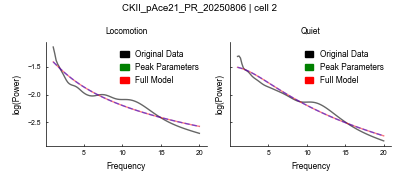

Saved to /Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4/figures/CKII_pooled/PSD_state_fooof_annotated_per_cell_1x2/CKII_pAce21_PR_20250806_cell3_fooof_1x2.svg


/opt/homebrew/Caskroom/miniforge/base/envs/AdamLab/lib/python3.11/site-packages/traitlets/traitlets.py:1385: DeprecationWarning: Passing unrecognized arguments to super(Toolbar).__init__().
NavigationToolbar2WebAgg.__init__() missing 1 required positional argument: 'canvas'
This is deprecated in traitlets 4.2.This error will be raised in a future release of traitlets.
  warn(


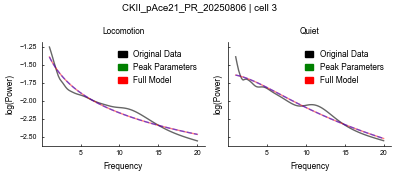

/opt/homebrew/Caskroom/miniforge/base/envs/AdamLab/lib/python3.11/site-packages/traitlets/traitlets.py:1385: DeprecationWarning: Passing unrecognized arguments to super(Toolbar).__init__().
NavigationToolbar2WebAgg.__init__() missing 1 required positional argument: 'canvas'
This is deprecated in traitlets 4.2.This error will be raised in a future release of traitlets.
  warn(


Saved to /Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4/figures/CKII_pooled/PSD_state_fooof_annotated_per_cell_1x2/CKII_pAce21_PR_20250806_cell4_fooof_1x2.svg


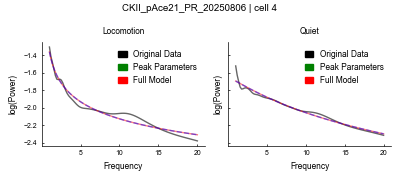

/opt/homebrew/Caskroom/miniforge/base/envs/AdamLab/lib/python3.11/site-packages/traitlets/traitlets.py:1385: DeprecationWarning: Passing unrecognized arguments to super(Toolbar).__init__().
NavigationToolbar2WebAgg.__init__() missing 1 required positional argument: 'canvas'
This is deprecated in traitlets 4.2.This error will be raised in a future release of traitlets.
  warn(


Saved to /Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4/figures/CKII_pooled/PSD_state_fooof_annotated_per_cell_1x2/CKII_pAce21_PR_20250806_cell5_fooof_1x2.svg


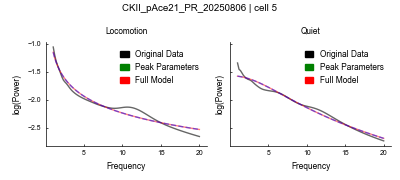

/opt/homebrew/Caskroom/miniforge/base/envs/AdamLab/lib/python3.11/site-packages/traitlets/traitlets.py:1385: DeprecationWarning: Passing unrecognized arguments to super(Toolbar).__init__().
NavigationToolbar2WebAgg.__init__() missing 1 required positional argument: 'canvas'
This is deprecated in traitlets 4.2.This error will be raised in a future release of traitlets.
  warn(


Saved to /Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4/figures/CKII_pooled/PSD_state_fooof_annotated_per_cell_1x2/CKII_pAce21_PR_20250806_cell6_fooof_1x2.svg


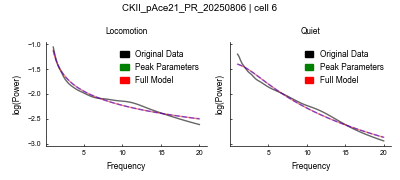

/opt/homebrew/Caskroom/miniforge/base/envs/AdamLab/lib/python3.11/site-packages/traitlets/traitlets.py:1385: DeprecationWarning: Passing unrecognized arguments to super(Toolbar).__init__().
NavigationToolbar2WebAgg.__init__() missing 1 required positional argument: 'canvas'
This is deprecated in traitlets 4.2.This error will be raised in a future release of traitlets.
  warn(


Saved to /Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4/figures/CKII_pooled/PSD_state_fooof_annotated_per_cell_1x2/CKII_pAce21_PR_20250806_cell7_fooof_1x2.svg


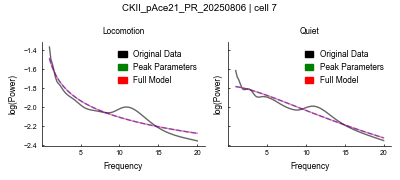

/opt/homebrew/Caskroom/miniforge/base/envs/AdamLab/lib/python3.11/site-packages/traitlets/traitlets.py:1385: DeprecationWarning: Passing unrecognized arguments to super(Toolbar).__init__().
NavigationToolbar2WebAgg.__init__() missing 1 required positional argument: 'canvas'
This is deprecated in traitlets 4.2.This error will be raised in a future release of traitlets.
  warn(


Saved to /Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4/figures/CKII_pooled/PSD_state_fooof_annotated_per_cell_1x2/CKII_pAce21_PR_20250806_cell8_fooof_1x2.svg


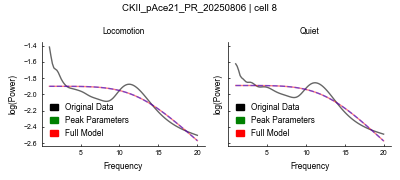

/opt/homebrew/Caskroom/miniforge/base/envs/AdamLab/lib/python3.11/site-packages/traitlets/traitlets.py:1385: DeprecationWarning: Passing unrecognized arguments to super(Toolbar).__init__().
NavigationToolbar2WebAgg.__init__() missing 1 required positional argument: 'canvas'
This is deprecated in traitlets 4.2.This error will be raised in a future release of traitlets.
  warn(


Saved to /Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4/figures/CKII_pooled/PSD_state_fooof_annotated_per_cell_1x2/CKII_pAce45_PX_20260118_cell0_fooof_1x2.svg


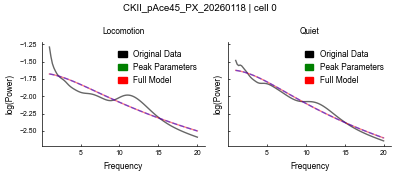

/opt/homebrew/Caskroom/miniforge/base/envs/AdamLab/lib/python3.11/site-packages/traitlets/traitlets.py:1385: DeprecationWarning: Passing unrecognized arguments to super(Toolbar).__init__().
NavigationToolbar2WebAgg.__init__() missing 1 required positional argument: 'canvas'
This is deprecated in traitlets 4.2.This error will be raised in a future release of traitlets.
  warn(


Saved to /Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4/figures/CKII_pooled/PSD_state_fooof_annotated_per_cell_1x2/CKII_pAce45_PX_20260118_cell1_fooof_1x2.svg


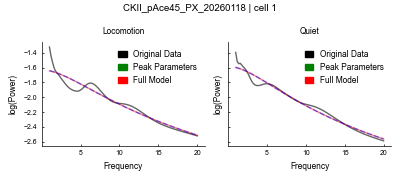

/opt/homebrew/Caskroom/miniforge/base/envs/AdamLab/lib/python3.11/site-packages/traitlets/traitlets.py:1385: DeprecationWarning: Passing unrecognized arguments to super(Toolbar).__init__().
NavigationToolbar2WebAgg.__init__() missing 1 required positional argument: 'canvas'
This is deprecated in traitlets 4.2.This error will be raised in a future release of traitlets.
  warn(


Saved to /Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4/figures/CKII_pooled/PSD_state_fooof_annotated_per_cell_1x2/CKII_pAce45_PX_20260118_cell2_fooof_1x2.svg


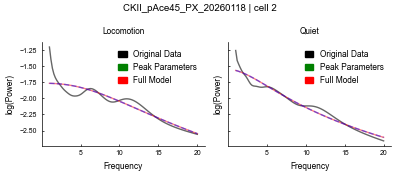

/opt/homebrew/Caskroom/miniforge/base/envs/AdamLab/lib/python3.11/site-packages/traitlets/traitlets.py:1385: DeprecationWarning: Passing unrecognized arguments to super(Toolbar).__init__().
NavigationToolbar2WebAgg.__init__() missing 1 required positional argument: 'canvas'
This is deprecated in traitlets 4.2.This error will be raised in a future release of traitlets.
  warn(


Saved to /Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4/figures/CKII_pooled/PSD_state_fooof_annotated_per_cell_1x2/CKII_pAce45_PX_20260118_cell3_fooof_1x2.svg


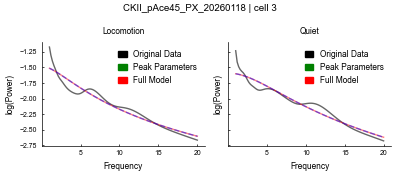

/opt/homebrew/Caskroom/miniforge/base/envs/AdamLab/lib/python3.11/site-packages/traitlets/traitlets.py:1385: DeprecationWarning: Passing unrecognized arguments to super(Toolbar).__init__().
NavigationToolbar2WebAgg.__init__() missing 1 required positional argument: 'canvas'
This is deprecated in traitlets 4.2.This error will be raised in a future release of traitlets.
  warn(


Saved to /Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4/figures/CKII_pooled/PSD_state_fooof_annotated_per_cell_1x2/CKII_pAce45_PX_20260118_cell4_fooof_1x2.svg


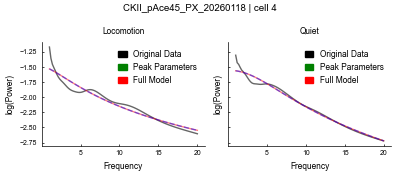

/opt/homebrew/Caskroom/miniforge/base/envs/AdamLab/lib/python3.11/site-packages/traitlets/traitlets.py:1385: DeprecationWarning: Passing unrecognized arguments to super(Toolbar).__init__().
NavigationToolbar2WebAgg.__init__() missing 1 required positional argument: 'canvas'
This is deprecated in traitlets 4.2.This error will be raised in a future release of traitlets.
  warn(


Saved to /Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4/figures/CKII_pooled/PSD_state_fooof_annotated_per_cell_1x2/CKII_pAce45_PX_20260118_cell5_fooof_1x2.svg


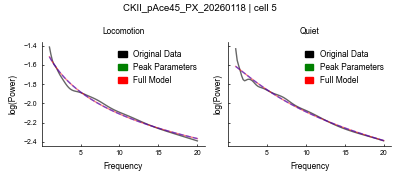

Saved to /Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4/figures/CKII_pooled/PSD_state_fooof_annotated_per_cell_1x2/CKII_pAce45_PX_20260118_cell6_fooof_1x2.svg


/var/folders/8g/cpkd0cfs4gn915zwbfdfgf9w0000gn/T/ipykernel_58686/3001785957.py:45: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig, axes = plt.subplots(1, 2, figsize=(4.0, 1.8), sharex=True, sharey=True)
/opt/homebrew/Caskroom/miniforge/base/envs/AdamLab/lib/python3.11/site-packages/traitlets/traitlets.py:1385: DeprecationWarning: Passing unrecognized arguments to super(Toolbar).__init__().
NavigationToolbar2WebAgg.__init__() missing 1 required positional argument: 'canvas'
This is deprecated in traitlets 4.2.This error will be raised in a future release of traitlets.
  warn(


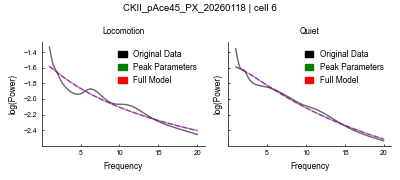

/opt/homebrew/Caskroom/miniforge/base/envs/AdamLab/lib/python3.11/site-packages/traitlets/traitlets.py:1385: DeprecationWarning: Passing unrecognized arguments to super(Toolbar).__init__().
NavigationToolbar2WebAgg.__init__() missing 1 required positional argument: 'canvas'
This is deprecated in traitlets 4.2.This error will be raised in a future release of traitlets.
  warn(


Saved to /Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4/figures/CKII_pooled/PSD_state_fooof_annotated_per_cell_1x2/CKII_pAce45_PX_20260118_cell7_fooof_1x2.svg


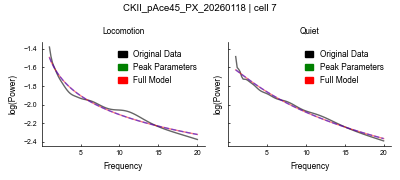

/opt/homebrew/Caskroom/miniforge/base/envs/AdamLab/lib/python3.11/site-packages/traitlets/traitlets.py:1385: DeprecationWarning: Passing unrecognized arguments to super(Toolbar).__init__().
NavigationToolbar2WebAgg.__init__() missing 1 required positional argument: 'canvas'
This is deprecated in traitlets 4.2.This error will be raised in a future release of traitlets.
  warn(


Saved to /Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4/figures/CKII_pooled/PSD_state_fooof_annotated_per_cell_1x2/CKII_pAce45_PX_20260118_cell8_fooof_1x2.svg


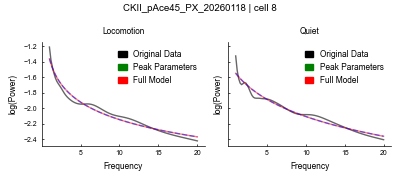

/opt/homebrew/Caskroom/miniforge/base/envs/AdamLab/lib/python3.11/site-packages/traitlets/traitlets.py:1385: DeprecationWarning: Passing unrecognized arguments to super(Toolbar).__init__().
NavigationToolbar2WebAgg.__init__() missing 1 required positional argument: 'canvas'
This is deprecated in traitlets 4.2.This error will be raised in a future release of traitlets.
  warn(


Saved to /Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4/figures/CKII_pooled/PSD_state_fooof_annotated_per_cell_1x2/CKII_pAce45_PX_20260118_cell9_fooof_1x2.svg


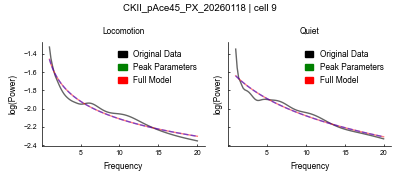

/opt/homebrew/Caskroom/miniforge/base/envs/AdamLab/lib/python3.11/site-packages/traitlets/traitlets.py:1385: DeprecationWarning: Passing unrecognized arguments to super(Toolbar).__init__().
NavigationToolbar2WebAgg.__init__() missing 1 required positional argument: 'canvas'
This is deprecated in traitlets 4.2.This error will be raised in a future release of traitlets.
  warn(


Saved to /Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4/figures/CKII_pooled/PSD_state_fooof_annotated_per_cell_1x2/CKII_pAce45_PX_20260118_cell10_fooof_1x2.svg


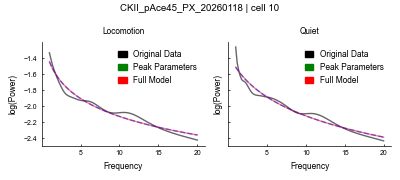

/opt/homebrew/Caskroom/miniforge/base/envs/AdamLab/lib/python3.11/site-packages/traitlets/traitlets.py:1385: DeprecationWarning: Passing unrecognized arguments to super(Toolbar).__init__().
NavigationToolbar2WebAgg.__init__() missing 1 required positional argument: 'canvas'
This is deprecated in traitlets 4.2.This error will be raised in a future release of traitlets.
  warn(


Saved to /Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4/figures/CKII_pooled/PSD_state_fooof_annotated_per_cell_1x2/CKII_pAce45_PX_20260118_cell11_fooof_1x2.svg


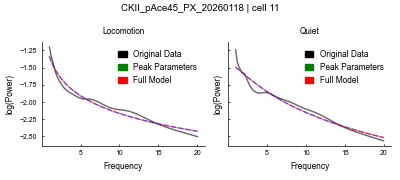

Saved to /Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4/figures/CKII_pooled/PSD_state_fooof_annotated_per_cell_1x2/CKII_pAce45_PX_20260118_cell12_fooof_1x2.svg


/opt/homebrew/Caskroom/miniforge/base/envs/AdamLab/lib/python3.11/site-packages/traitlets/traitlets.py:1385: DeprecationWarning: Passing unrecognized arguments to super(Toolbar).__init__().
NavigationToolbar2WebAgg.__init__() missing 1 required positional argument: 'canvas'
This is deprecated in traitlets 4.2.This error will be raised in a future release of traitlets.
  warn(


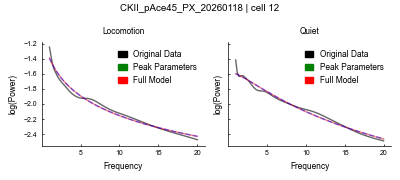

/opt/homebrew/Caskroom/miniforge/base/envs/AdamLab/lib/python3.11/site-packages/traitlets/traitlets.py:1385: DeprecationWarning: Passing unrecognized arguments to super(Toolbar).__init__().
NavigationToolbar2WebAgg.__init__() missing 1 required positional argument: 'canvas'
This is deprecated in traitlets 4.2.This error will be raised in a future release of traitlets.
  warn(


Saved to /Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4/figures/CKII_pooled/PSD_state_fooof_annotated_per_cell_1x2/CKII_pAce45_PX_20260118_cell13_fooof_1x2.svg


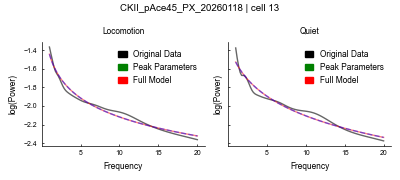

/opt/homebrew/Caskroom/miniforge/base/envs/AdamLab/lib/python3.11/site-packages/traitlets/traitlets.py:1385: DeprecationWarning: Passing unrecognized arguments to super(Toolbar).__init__().
NavigationToolbar2WebAgg.__init__() missing 1 required positional argument: 'canvas'
This is deprecated in traitlets 4.2.This error will be raised in a future release of traitlets.
  warn(


Saved to /Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4/figures/CKII_pooled/PSD_state_fooof_annotated_per_cell_1x2/CKII_pAce45_PX_20260118_cell14_fooof_1x2.svg


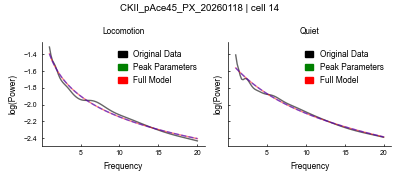

Saved to /Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4/figures/CKII_pooled/PSD_state_fooof_annotated_per_cell_1x2/CKII_pAce45_PX_20260118_cell15_fooof_1x2.svg


/opt/homebrew/Caskroom/miniforge/base/envs/AdamLab/lib/python3.11/site-packages/traitlets/traitlets.py:1385: DeprecationWarning: Passing unrecognized arguments to super(Toolbar).__init__().
NavigationToolbar2WebAgg.__init__() missing 1 required positional argument: 'canvas'
This is deprecated in traitlets 4.2.This error will be raised in a future release of traitlets.
  warn(


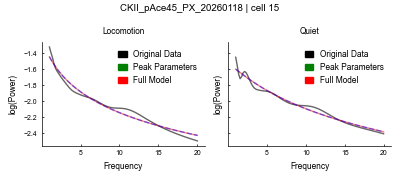

/opt/homebrew/Caskroom/miniforge/base/envs/AdamLab/lib/python3.11/site-packages/traitlets/traitlets.py:1385: DeprecationWarning: Passing unrecognized arguments to super(Toolbar).__init__().
NavigationToolbar2WebAgg.__init__() missing 1 required positional argument: 'canvas'
This is deprecated in traitlets 4.2.This error will be raised in a future release of traitlets.
  warn(


Saved to /Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4/figures/CKII_pooled/PSD_state_fooof_annotated_per_cell_1x2/CKII_pAce47_PX_20260128_cell0_fooof_1x2.svg


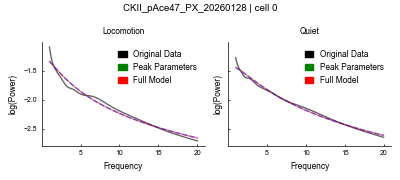

Saved to /Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4/figures/CKII_pooled/PSD_state_fooof_annotated_per_cell_1x2/CKII_pAce47_PX_20260128_cell1_fooof_1x2.svg


/opt/homebrew/Caskroom/miniforge/base/envs/AdamLab/lib/python3.11/site-packages/traitlets/traitlets.py:1385: DeprecationWarning: Passing unrecognized arguments to super(Toolbar).__init__().
NavigationToolbar2WebAgg.__init__() missing 1 required positional argument: 'canvas'
This is deprecated in traitlets 4.2.This error will be raised in a future release of traitlets.
  warn(


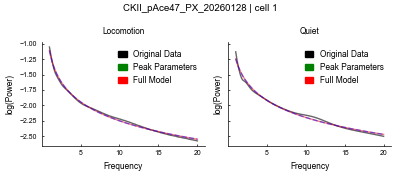

/opt/homebrew/Caskroom/miniforge/base/envs/AdamLab/lib/python3.11/site-packages/traitlets/traitlets.py:1385: DeprecationWarning: Passing unrecognized arguments to super(Toolbar).__init__().
NavigationToolbar2WebAgg.__init__() missing 1 required positional argument: 'canvas'
This is deprecated in traitlets 4.2.This error will be raised in a future release of traitlets.
  warn(


Saved to /Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4/figures/CKII_pooled/PSD_state_fooof_annotated_per_cell_1x2/CKII_pAce47_PX_20260128_cell2_fooof_1x2.svg


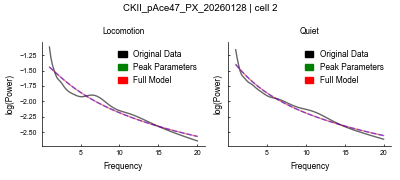

/opt/homebrew/Caskroom/miniforge/base/envs/AdamLab/lib/python3.11/site-packages/traitlets/traitlets.py:1385: DeprecationWarning: Passing unrecognized arguments to super(Toolbar).__init__().
NavigationToolbar2WebAgg.__init__() missing 1 required positional argument: 'canvas'
This is deprecated in traitlets 4.2.This error will be raised in a future release of traitlets.
  warn(


Saved to /Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4/figures/CKII_pooled/PSD_state_fooof_annotated_per_cell_1x2/CKII_pAce47_PX_20260128_cell3_fooof_1x2.svg


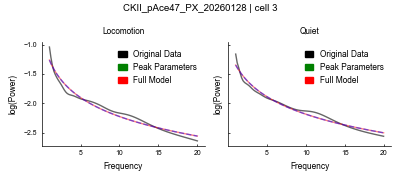

/opt/homebrew/Caskroom/miniforge/base/envs/AdamLab/lib/python3.11/site-packages/traitlets/traitlets.py:1385: DeprecationWarning: Passing unrecognized arguments to super(Toolbar).__init__().
NavigationToolbar2WebAgg.__init__() missing 1 required positional argument: 'canvas'
This is deprecated in traitlets 4.2.This error will be raised in a future release of traitlets.
  warn(


Saved to /Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4/figures/CKII_pooled/PSD_state_fooof_annotated_per_cell_1x2/CKII_pAce47_PX_20260128_cell4_fooof_1x2.svg


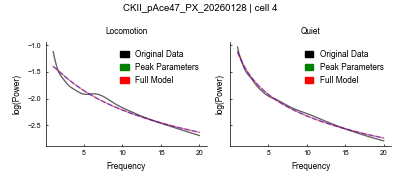

/opt/homebrew/Caskroom/miniforge/base/envs/AdamLab/lib/python3.11/site-packages/traitlets/traitlets.py:1385: DeprecationWarning: Passing unrecognized arguments to super(Toolbar).__init__().
NavigationToolbar2WebAgg.__init__() missing 1 required positional argument: 'canvas'
This is deprecated in traitlets 4.2.This error will be raised in a future release of traitlets.
  warn(


Saved to /Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4/figures/CKII_pooled/PSD_state_fooof_annotated_per_cell_1x2/CKII_pAce38_PX_20251126_cell0_fooof_1x2.svg


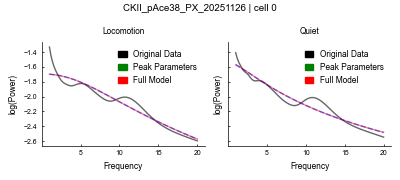

/opt/homebrew/Caskroom/miniforge/base/envs/AdamLab/lib/python3.11/site-packages/traitlets/traitlets.py:1385: DeprecationWarning: Passing unrecognized arguments to super(Toolbar).__init__().
NavigationToolbar2WebAgg.__init__() missing 1 required positional argument: 'canvas'
This is deprecated in traitlets 4.2.This error will be raised in a future release of traitlets.
  warn(


Saved to /Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4/figures/CKII_pooled/PSD_state_fooof_annotated_per_cell_1x2/CKII_pAce38_PX_20251126_cell1_fooof_1x2.svg


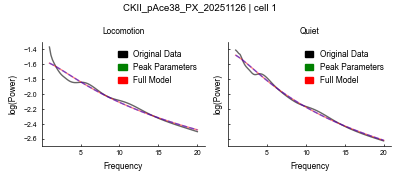

/opt/homebrew/Caskroom/miniforge/base/envs/AdamLab/lib/python3.11/site-packages/traitlets/traitlets.py:1385: DeprecationWarning: Passing unrecognized arguments to super(Toolbar).__init__().
NavigationToolbar2WebAgg.__init__() missing 1 required positional argument: 'canvas'
This is deprecated in traitlets 4.2.This error will be raised in a future release of traitlets.
  warn(


Saved to /Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4/figures/CKII_pooled/PSD_state_fooof_annotated_per_cell_1x2/CKII_pAce38_PX_20251126_cell2_fooof_1x2.svg


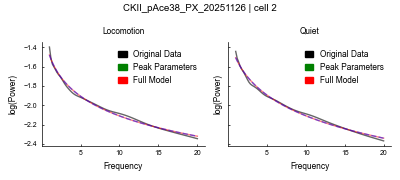

Saved to /Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4/figures/CKII_pooled/PSD_state_fooof_annotated_per_cell_1x2/CKII_pAce38_PX_20251126_cell3_fooof_1x2.svg


/opt/homebrew/Caskroom/miniforge/base/envs/AdamLab/lib/python3.11/site-packages/traitlets/traitlets.py:1385: DeprecationWarning: Passing unrecognized arguments to super(Toolbar).__init__().
NavigationToolbar2WebAgg.__init__() missing 1 required positional argument: 'canvas'
This is deprecated in traitlets 4.2.This error will be raised in a future release of traitlets.
  warn(


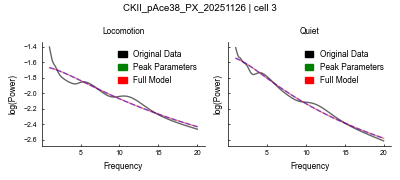

/opt/homebrew/Caskroom/miniforge/base/envs/AdamLab/lib/python3.11/site-packages/traitlets/traitlets.py:1385: DeprecationWarning: Passing unrecognized arguments to super(Toolbar).__init__().
NavigationToolbar2WebAgg.__init__() missing 1 required positional argument: 'canvas'
This is deprecated in traitlets 4.2.This error will be raised in a future release of traitlets.
  warn(


Saved to /Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4/figures/CKII_pooled/PSD_state_fooof_annotated_per_cell_1x2/CKII_pAce38_PX_20251126_cell4_fooof_1x2.svg


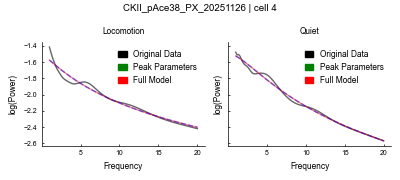

/opt/homebrew/Caskroom/miniforge/base/envs/AdamLab/lib/python3.11/site-packages/traitlets/traitlets.py:1385: DeprecationWarning: Passing unrecognized arguments to super(Toolbar).__init__().
NavigationToolbar2WebAgg.__init__() missing 1 required positional argument: 'canvas'
This is deprecated in traitlets 4.2.This error will be raised in a future release of traitlets.
  warn(


Saved to /Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4/figures/CKII_pooled/PSD_state_fooof_annotated_per_cell_1x2/CKII_pAce38_PX_20251126_cell5_fooof_1x2.svg


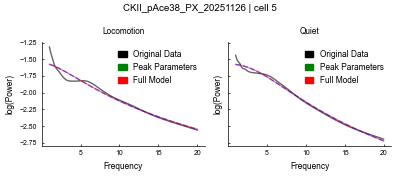

/opt/homebrew/Caskroom/miniforge/base/envs/AdamLab/lib/python3.11/site-packages/traitlets/traitlets.py:1385: DeprecationWarning: Passing unrecognized arguments to super(Toolbar).__init__().
NavigationToolbar2WebAgg.__init__() missing 1 required positional argument: 'canvas'
This is deprecated in traitlets 4.2.This error will be raised in a future release of traitlets.
  warn(


Saved to /Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4/figures/CKII_pooled/PSD_state_fooof_annotated_per_cell_1x2/CKII_pAce38_PX_20251126_cell6_fooof_1x2.svg


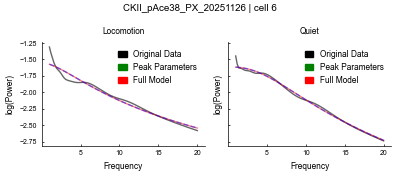

/opt/homebrew/Caskroom/miniforge/base/envs/AdamLab/lib/python3.11/site-packages/traitlets/traitlets.py:1385: DeprecationWarning: Passing unrecognized arguments to super(Toolbar).__init__().
NavigationToolbar2WebAgg.__init__() missing 1 required positional argument: 'canvas'
This is deprecated in traitlets 4.2.This error will be raised in a future release of traitlets.
  warn(


Saved to /Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4/figures/CKII_pooled/PSD_state_fooof_annotated_per_cell_1x2/CKII_pAce38_PX_20251126_cell7_fooof_1x2.svg


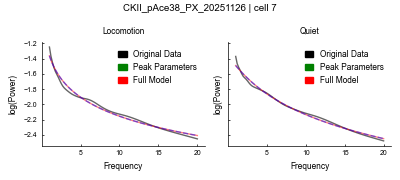

/opt/homebrew/Caskroom/miniforge/base/envs/AdamLab/lib/python3.11/site-packages/traitlets/traitlets.py:1385: DeprecationWarning: Passing unrecognized arguments to super(Toolbar).__init__().
NavigationToolbar2WebAgg.__init__() missing 1 required positional argument: 'canvas'
This is deprecated in traitlets 4.2.This error will be raised in a future release of traitlets.
  warn(


Saved to /Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4/figures/CKII_pooled/PSD_state_fooof_annotated_per_cell_1x2/CKII_pAce38_PX_20251126_cell8_fooof_1x2.svg


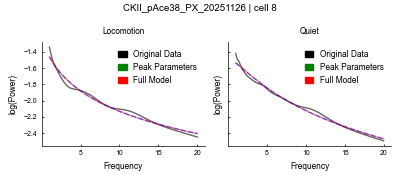

In [13]:
# Plot per-cell annotated FOOOF fits for both states (1x2)
save_plots = True
show_plots = True
max_cells_per_dataset = None  # set to an int to limit (e.g. 10)

annotated_save_folder = os.path.join(figure_save_folder, 'PSD_state_fooof_annotated_per_cell_1x2')
os.makedirs(annotated_save_folder, exist_ok=True)

for npz_path in npz_files:
    data = np.load(npz_path, allow_pickle=True)
    dataset_name = os.path.basename(os.path.dirname(npz_path))
    freqs = data['freqs']
    psd_move_cells = data['psd_move_cells']
    psd_quiet_cells = data['psd_quiet_cells']

    if freqs_ref is not None and not np.array_equal(freqs, freqs_ref):
        print(f'Skipping {dataset_name}: frequency mismatch')
        continue

    n_cells = int(min(psd_move_cells.shape[0], psd_quiet_cells.shape[0]))
    cell_ids = list(range(n_cells))
    if max_cells_per_dataset is not None:
        cell_ids = cell_ids[:max_cells_per_dataset]

    # Optional normalization (match the pooled normalization above)
    do_norm = bool(normalize_by_freq_range) and (freqs_ref is not None)
    norm_mask_local = None
    if do_norm:
        norm_mask_local = (freqs_ref >= norm_freq_min) & (freqs_ref <= norm_freq_max)
        if not np.any(norm_mask_local):
            norm_mask_local = None

    for cell_idx in cell_ids:
        psd_move = psd_move_cells[cell_idx].astype(float, copy=True)
        psd_quiet = psd_quiet_cells[cell_idx].astype(float, copy=True)

        if norm_mask_local is not None:
            total_power_move = np.nansum(psd_move[norm_mask_local])
            total_power_quiet = np.nansum(psd_quiet[norm_mask_local])
            if total_power_move > 0:
                psd_move = psd_move / total_power_move
            if total_power_quiet > 0:
                psd_quiet = psd_quiet / total_power_quiet

        fig, axes = plt.subplots(1, 2, figsize=(4.0, 1.8), sharex=True, sharey=True)

        for ax, state, psd in [
            (axes[0], 'moving', psd_move),
            (axes[1], 'quiet', psd_quiet),
        ]:

            fm = FOOOF(
                min_peak_height=min_peak_height,
                aperiodic_mode=aperiodic_mode,
                peak_width_limits=peak_width_limits,
                peak_threshold=peak_threshold,
                max_n_peaks=max_n_peaks,
                verbose=False,
            )

            fm.fit(freqs, psd, freq_range)
            plot_annotated_model(
                fm,
                annotate_peaks=True,
                annotate_aperiodic=False,
                plt_log=False,
                ax=ax,
            )

            # Reset styling (FOOOF can override tick params)
            ax.tick_params(axis='both', which='major', labelsize=5, length=1.75, width=0.5, direction='in')
            ax.set_xlabel('Frequency', fontsize=6)
            ax.set_ylabel('log(Power)', fontsize=6)
            for line in ax.get_lines():
                line.set_linewidth(1.0)
            ax.spines['top'].set_visible(False)
            ax.spines['right'].set_visible(False)

            title = 'Locomotion' if state == 'moving' else 'Quiet'
            ax.set_title(title, fontsize=6)

        fig.suptitle(f'{dataset_name} | cell {cell_idx}', fontsize=7)
        plt.tight_layout()

        if save_plots:
            out_path = os.path.join(annotated_save_folder, f'{dataset_name}_cell{cell_idx}_fooof_1x2.svg')
            fig.savefig(out_path, dpi=300)
            print(f'Saved to {out_path}')

        if show_plots:
            plt.show()
        else:
            plt.close(fig)


# Population fitting


In [9]:
# Model settings
bands = Bands({'theta': [4, 8.5],
               'alpha': [8.5, 12]})
peak_width = [0.5, 4]
n_peaks = 2
peak_height = 0.2
aperiodic_mode = 'knee'  # 'knee' or 'fixed'
PSD_range = [1, 20]

states = ['moving', 'quiet']
spectra_map = {
    'moving': psd_run_all,
    'quiet': psd_rest_all,
}
color_map_state = {
    'moving': moving_color,
    'quiet': quiet_color,
}
label_map_state = {
    'moving': 'Locomotion',
    'quiet': 'Quiet',
}

if freqs_ref is None or len(psd_run_all) == 0 or len(psd_rest_all) == 0:
    raise ValueError('No valid pooled PSD data loaded (run the pooling cells above).')

fg_results = {}
theta_results = {}
alpha_results = {}

for state in states:
    spectra = np.asarray(spectra_map[state])
    print(f'{state}: {spectra.shape[0]} cells')

    fg = FOOOFGroup(
        peak_width_limits=peak_width,
        max_n_peaks=n_peaks,
        min_peak_height=peak_height,
        aperiodic_mode=aperiodic_mode,
        verbose=False,
    )
    fg.fit(freqs_ref, spectra, PSD_range)

    theta_results[state] = get_band_peak_fg(fg, bands.theta)
    alpha_results[state] = get_band_peak_fg(fg, bands.alpha)
    fg_results[state] = fg

print('\nPopulation fitting complete for both states.')


moving: 39 cells
quiet: 39 cells

Population fitting complete for both states.


Saved to /Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4/figures/CKII_pooled/PSD_state_fooof_theta_peak_params.svg


/opt/homebrew/Caskroom/miniforge/base/envs/AdamLab/lib/python3.11/site-packages/traitlets/traitlets.py:1385: DeprecationWarning: Passing unrecognized arguments to super(Toolbar).__init__().
NavigationToolbar2WebAgg.__init__() missing 1 required positional argument: 'canvas'
This is deprecated in traitlets 4.2.This error will be raised in a future release of traitlets.
  warn(


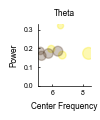

Saved to /Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4/figures/CKII_pooled/PSD_state_fooof_alpha_peak_params.svg


/opt/homebrew/Caskroom/miniforge/base/envs/AdamLab/lib/python3.11/site-packages/traitlets/traitlets.py:1385: DeprecationWarning: Passing unrecognized arguments to super(Toolbar).__init__().
NavigationToolbar2WebAgg.__init__() missing 1 required positional argument: 'canvas'
This is deprecated in traitlets 4.2.This error will be raised in a future release of traitlets.
  warn(


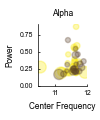

Saved to /Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4/figures/CKII_pooled/PSD_state_fooof_theta_peak_fits.svg


/opt/homebrew/Caskroom/miniforge/base/envs/AdamLab/lib/python3.11/site-packages/traitlets/traitlets.py:1385: DeprecationWarning: Passing unrecognized arguments to super(Toolbar).__init__().
NavigationToolbar2WebAgg.__init__() missing 1 required positional argument: 'canvas'
This is deprecated in traitlets 4.2.This error will be raised in a future release of traitlets.
  warn(


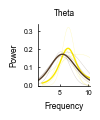

/opt/homebrew/Caskroom/miniforge/base/envs/AdamLab/lib/python3.11/site-packages/traitlets/traitlets.py:1385: DeprecationWarning: Passing unrecognized arguments to super(Toolbar).__init__().
NavigationToolbar2WebAgg.__init__() missing 1 required positional argument: 'canvas'
This is deprecated in traitlets 4.2.This error will be raised in a future release of traitlets.
  warn(


Saved to /Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4/figures/CKII_pooled/PSD_state_fooof_alpha_peak_fits.svg


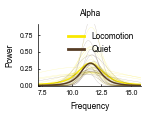

In [10]:
# Plot peak parameters and peak fits (theta + alpha)

from matplotlib.lines import Line2D

def _add_state_legend(ax):
    handles = [
        Line2D([0], [0], color=color_map_state['moving'], lw=2, label=label_map_state['moving']),
        Line2D([0], [0], color=color_map_state['quiet'], lw=2, label=label_map_state['quiet']),
    ]
    ax.legend(handles=handles, frameon=False, fontsize=6)

# Theta peak params (single axis)
fig, ax = plt.subplots(1, 1, figsize=(1.0, 1.2))
for state in states:
    plot_peak_params(theta_results[state], ax=ax, colors=color_map_state[state], alpha=0.3, s=18)
ax.set_xlabel('Center Frequency', fontsize=6)
ax.set_ylabel('Power', fontsize=6)
ax.set_title('Theta', fontsize=6)
ax.tick_params(axis='both', which='major', labelsize=5, length=1.75, width=0.5, direction='in')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
#_add_state_legend(ax)
plt.tight_layout()
out_path = os.path.join(figure_save_folder, 'PSD_state_fooof_theta_peak_params.svg')
fig.savefig(out_path, dpi=300)
print(f'Saved to {out_path}')
plt.show()

# Alpha peak params (single axis)
fig, ax = plt.subplots(1, 1, figsize=(1.0, 1.2))
for state in states:
    plot_peak_params(alpha_results[state], ax=ax, colors=color_map_state[state], alpha=0.3, s=18)
ax.set_xlabel('Center Frequency', fontsize=6)
ax.set_ylabel('Power', fontsize=6)
ax.set_title('Alpha', fontsize=6)
ax.tick_params(axis='both', which='major', labelsize=5, length=1.75, width=0.5, direction='in')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
#_add_state_legend(ax)
plt.tight_layout()
out_path = os.path.join(figure_save_folder, 'PSD_state_fooof_alpha_peak_params.svg')
fig.savefig(out_path, dpi=300)
print(f'Saved to {out_path}')
plt.show()

# Peak fits (theta): Locomotion + Quiet on one axis
fig, ax = plt.subplots(1, 1, figsize=(1.0, 1.2))
for state in states:
    plot_peak_fits(theta_results[state], ax=ax, colors=color_map_state[state])
ax.set_xlabel('Frequency', fontsize=6)
ax.set_ylabel('Power', fontsize=6)
ax.set_title('Theta', fontsize=6)
ax.tick_params(axis='both', which='major', labelsize=5, length=1.75, width=0.5, direction='in')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
#_add_state_legend(ax)
plt.tight_layout()
out_path = os.path.join(figure_save_folder, 'PSD_state_fooof_theta_peak_fits.svg')
fig.savefig(out_path, dpi=300)
print(f'Saved to {out_path}')
plt.show()

# Peak fits (alpha): Locomotion + Quiet on one axis
fig, ax = plt.subplots(1, 1, figsize=(1.5, 1.2))
for state in states:
    plot_peak_fits(alpha_results[state], ax=ax, colors=color_map_state[state])
ax.set_xlabel('Frequency', fontsize=6)
ax.set_ylabel('Power', fontsize=6)
ax.set_title('Alpha', fontsize=6)
ax.tick_params(axis='both', which='major', labelsize=5, length=1.75, width=0.5, direction='in')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
_add_state_legend(ax)
plt.tight_layout()
out_path = os.path.join(figure_save_folder, 'PSD_state_fooof_alpha_peak_fits.svg')
fig.savefig(out_path, dpi=300)
print(f'Saved to {out_path}')
plt.show()


=== Theta peak detection rate ===
   moving: 4/39 = 10.3%
    quiet: 4/39 = 10.3%

=== Alpha peak detection rate ===
   moving: 23/39 = 59.0%
    quiet: 20/39 = 51.3%
Saved to /Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4/figures/CKII_pooled/PSD_state_fooof_theta_metrics_violin.svg


/opt/homebrew/Caskroom/miniforge/base/envs/AdamLab/lib/python3.11/site-packages/traitlets/traitlets.py:1385: DeprecationWarning: Passing unrecognized arguments to super(Toolbar).__init__().
NavigationToolbar2WebAgg.__init__() missing 1 required positional argument: 'canvas'
This is deprecated in traitlets 4.2.This error will be raised in a future release of traitlets.
  warn(


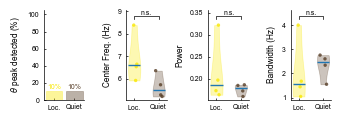

/opt/homebrew/Caskroom/miniforge/base/envs/AdamLab/lib/python3.11/site-packages/traitlets/traitlets.py:1385: DeprecationWarning: Passing unrecognized arguments to super(Toolbar).__init__().
NavigationToolbar2WebAgg.__init__() missing 1 required positional argument: 'canvas'
This is deprecated in traitlets 4.2.This error will be raised in a future release of traitlets.
  warn(


Saved to /Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4/figures/CKII_pooled/PSD_state_fooof_alpha_metrics_violin.svg


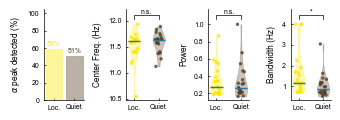


=== Statistical Tests (FOOOF metrics) ===

--- Theta ---
     CF: Loc (n=4) vs Quiet (n=4)  U=15.0, p=0.0571 n.s.
  Power: Loc (n=4) vs Quiet (n=4)  U=11.0, p=0.486 n.s.
     BW: Loc (n=4) vs Quiet (n=4)  U=5.0, p=0.486 n.s.
    AUC: Loc (n=4) vs Quiet (n=4)  U=5.0, p=0.486 n.s.
  detect: Loc 4/39 vs Quiet 4/39  p=1 n.s.

--- Alpha ---
     CF: Loc (n=23) vs Quiet (n=20)  U=193.0, p=0.374 n.s.
  Power: Loc (n=23) vs Quiet (n=20)  U=231.0, p=0.99 n.s.
     BW: Loc (n=23) vs Quiet (n=20)  U=320.0, p=0.0293 *
    AUC: Loc (n=23) vs Quiet (n=20)  U=285.0, p=0.184 n.s.
  detect: Loc 23/39 vs Quiet 20/39  p=0.649 n.s.


In [11]:
# Extract peak metrics (theta + alpha) and plot 2-state violin summaries
# Columns from get_band_peak_fg: [CF, Power, BW]

def band_auc_from_fg(fg, idx, band, clip_zero=True, space='linear'):
    """Integrate periodic component within a frequency band."""
    try:
        fm = fg.get_fooof(idx, regenerate=True)
        freqs = fm.freqs
        f_lo, f_hi = band
        mask = (freqs >= f_lo) & (freqs <= f_hi)
        if not np.any(mask):
            return np.nan
        peak = fm.get_model('peak', space=space)
        vals = peak[mask]
        if clip_zero:
            vals = np.clip(vals, 0, None)
        return float(np.trapezoid(vals, freqs[mask]))
    except Exception:
        return np.nan

def build_metrics_df(peak_dict, fg_dict, band, states):
    rows = []
    detect_rows = []
    for state in states:
        peaks = peak_dict[state]
        fg = fg_dict[state]
        n_total = int(peaks.shape[0])
        n_detect = int(np.sum(~np.isnan(peaks[:, 0])))
        pct_detect = (100.0 * n_detect / n_total) if n_total else np.nan
        detect_rows.append({'state': state, 'n_total': n_total, 'n_detect': n_detect, 'pct_detect': pct_detect})

        for i in range(peaks.shape[0]):
            cf, pw, bw = peaks[i]
            if np.isnan(cf):
                continue
            auc = band_auc_from_fg(fg, i, band)
            rows.append({'state': state, 'cell_idx': i, 'CF': cf, 'Power': pw, 'BW': bw, 'AUC': auc})

    return pd.DataFrame(rows), pd.DataFrame(detect_rows)

df_theta, df_theta_detect = build_metrics_df(theta_results, fg_results, bands.theta, states)
df_alpha, df_alpha_detect = build_metrics_df(alpha_results, fg_results, bands.alpha, states)

print('=== Theta peak detection rate ===')
for _, row in df_theta_detect.sort_values('state').iterrows():
    print(f"  {row['state']:>7s}: {int(row['n_detect'])}/{int(row['n_total'])} = {row['pct_detect']:.1f}%")

print('\n=== Alpha peak detection rate ===')
for _, row in df_alpha_detect.sort_values('state').iterrows():
    print(f"  {row['state']:>7s}: {int(row['n_detect'])}/{int(row['n_total'])} = {row['pct_detect']:.1f}%")

def _sig(p):
    return '***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else 'n.s.'

def draw_bracket(ax, x1, x2, y, h, text, lw=0.5, fontsize=5, color='k', text_pad=0):
    ax.plot([x1, x1, x2, x2], [y, y + h, y + h, y], lw=lw, color=color, clip_on=False)
    ax.text((x1 + x2) / 2, y + h + text_pad, text, ha='center', va='bottom', fontsize=fontsize, color=color)

VIOLIN_MEDIAN_COLOR = '#1F77B4'

def plot_two_state_metrics(df_metrics, df_detect, band_name, out_name, plot_auc=False):
    if str(band_name).lower().startswith('theta'):
        detect_label = r'$\theta$ peak detected (%)'
    elif str(band_name).lower().startswith('alpha'):
        detect_label = r'$\alpha$ peak detected (%)'
    else:
        detect_label = f'{band_name} peak detected (%)'

    metric_names = ['pct_detect', 'CF', 'Power', 'BW'] + (['AUC'] if plot_auc else [])
    metric_labels = [detect_label, 'Center Freq. (Hz)', 'Power', 'Bandwidth (Hz)'] + (['AUC'] if plot_auc else [])
    pos_map = {'moving': 0, 'quiet': 1}
    x_positions = [pos_map['moving'], pos_map['quiet']]
    x_labels = ['Loc.', 'Quiet']

    n_panels = len(metric_names)
    fig, axes = plt.subplots(1, n_panels, figsize=(0.85 * n_panels, 1.2))
    axes = np.atleast_1d(axes)
    for ax, metric, title in zip(axes, metric_names, metric_labels):
        if metric == 'pct_detect':
            for state in states:
                row = df_detect[df_detect['state'] == state]
                if row.empty:
                    continue
                pct = float(row['pct_detect'].iloc[0])
                if np.isnan(pct):
                    continue
                pos = pos_map[state]
                c = color_map_state[state]
                ax.bar(pos, pct, width=0.8, color=c, alpha=0.4, edgecolor=c, linewidth=0.5, zorder=2)
                ax.text(pos, pct + 2, f'{pct:.0f}%', ha='center', va='bottom', fontsize=5, color=c)
            ax.set_ylim(0, 105)
            ax.set_xticks(x_positions)
            ax.set_xticklabels(x_labels)
            ax.set_ylabel(title, fontsize=6)
            ax.tick_params(axis='both', which='major', labelsize=5, length=1.75, width=0.5, direction='in')
            ax.spines['top'].set_visible(False)
            ax.spines['right'].set_visible(False)
            continue

        vals_mov = df_metrics.loc[df_metrics['state'] == 'moving', metric].dropna().values
        vals_qui = df_metrics.loc[df_metrics['state'] == 'quiet', metric].dropna().values

        # Only draw violins when both groups have enough samples
        if len(vals_mov) >= 2 and len(vals_qui) >= 2:
            parts = ax.violinplot([vals_mov, vals_qui], positions=x_positions, showmeans=False,
                                  showmedians=False, showextrema=False)
            for pc, state in zip(parts['bodies'], states):
                c = color_map_state[state]
                pc.set_facecolor(c)
                pc.set_edgecolor(c)
                pc.set_linewidth(0.5)
                pc.set_alpha(0.3)

        rng = np.random.default_rng(42)
        for vals, state in [(vals_mov, 'moving'), (vals_qui, 'quiet')]:
            if len(vals) == 0:
                continue
            pos = pos_map[state]
            c = color_map_state[state]
            jitter = rng.uniform(-0.15, 0.15, size=len(vals))
            ax.scatter(np.full_like(vals, pos) + jitter, vals, s=6, alpha=0.8, color=c, edgecolors='none', zorder=3)
            ax.hlines(np.median(vals), pos - 0.25, pos + 0.25, color=VIOLIN_MEDIAN_COLOR, linewidth=1.0, zorder=4)

        # Significance (unpaired) between states
        if len(vals_mov) >= 3 and len(vals_qui) >= 3:
            _, p = stats.mannwhitneyu(vals_mov, vals_qui, alternative='two-sided')
            y_max = np.max(np.concatenate([vals_mov, vals_qui]))
            y_min = np.min(np.concatenate([vals_mov, vals_qui]))
            y_range = (y_max - y_min) if y_max > y_min else 1.0
            y = y_max + y_range * 0.08
            h = y_range * 0.05
            draw_bracket(ax, x_positions[0], x_positions[1], y, h, _sig(p), fontsize=5)
            ax.set_ylim(y_min - y_range * 0.05, y + h + y_range * 0.08)

        ax.set_xticks(x_positions)
        ax.set_xticklabels(x_labels)
        ax.set_ylabel(title, fontsize=6)
        ax.tick_params(axis='both', which='major', labelsize=5, length=1.75, width=0.5, direction='in')
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)

    plt.tight_layout()
    out_path = os.path.join(figure_save_folder, out_name)
    fig.savefig(out_path, dpi=300)
    print(f'Saved to {out_path}')
    plt.show()

plot_two_state_metrics(df_theta, df_theta_detect, 'Theta', 'PSD_state_fooof_theta_metrics_violin.svg')
plot_two_state_metrics(df_alpha, df_alpha_detect, 'Alpha', 'PSD_state_fooof_alpha_metrics_violin.svg')

print('\n=== Statistical Tests (FOOOF metrics) ===')
for band_name, df_m, df_d in [('Theta', df_theta, df_theta_detect), ('Alpha', df_alpha, df_alpha_detect)]:
    print(f'\n--- {band_name} ---')
    for metric in ['CF', 'Power', 'BW', 'AUC']:
        vals_mov = df_m.loc[df_m['state'] == 'moving', metric].dropna().values
        vals_qui = df_m.loc[df_m['state'] == 'quiet', metric].dropna().values
        if len(vals_mov) >= 3 and len(vals_qui) >= 3:
            u_stat, u_p = stats.mannwhitneyu(vals_mov, vals_qui, alternative='two-sided')
            print(f'  {metric:>5s}: Loc (n={len(vals_mov)}) vs Quiet (n={len(vals_qui)})  U={u_stat:.1f}, p={u_p:.3g} {_sig(u_p)}')

    # Detection rate: Fisher exact test (2x2)
    rm = df_d[df_d['state'] == 'moving']
    rq = df_d[df_d['state'] == 'quiet']
    if (not rm.empty) and (not rq.empty):
        rm = rm.iloc[0]
        rq = rq.iloc[0]
        table_2x2 = [[int(rm['n_detect']), int(rm['n_total'] - rm['n_detect'])],
                     [int(rq['n_detect']), int(rq['n_total'] - rq['n_detect'])]]
        _, p = stats.fisher_exact(table_2x2)
        print(f"  detect: Loc {int(rm['n_detect'])}/{int(rm['n_total'])} vs Quiet {int(rq['n_detect'])}/{int(rq['n_total'])}  p={p:.3g} {_sig(p)}")
